## **Détection d'Équipements de Protection Individuelle**

**Auteurs :** Maram NASR et Skander HAJ MABROUK

**0.Installations et Imports**

In [2]:
!pip install -q torch torchvision
!pip install -q pycocotools

import torch
import torchvision
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F

**1.Configuration**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

CLASSES     = ["__background__", "casque", "gilet", "gants", "goggles", "boots", "masque"]
NUM_CLASSES = len(CLASSES)
CLASS2IDX   = {cls: idx for idx, cls in enumerate(CLASSES)}
IDX2CLASS   = {idx: cls for cls, idx in CLASS2IDX.items()}

CLASS_ALIASES = {
    "casque": "casque", "helmet" : "casque",
    "gilet" : "gilet",  "vest"   : "gilet",
    "gants" : "gants",  "gloves" : "gants",
    "goggles": "goggles", "googles": "goggles", "lunettes": "goggles",
    "boots" : "boots",  "bottes" : "boots",
    "masque": "masque", "mask"   : "masque",
}

ROOT             = "/content/drive/MyDrive/ObjectDetectionDataset"
TEST_DIR         = os.path.join(ROOT, "test")
TEST_CSV         = os.path.join(TEST_DIR, "_annotations.csv")
BEST_MODEL_PATH  = os.path.join(ROOT, "best_model_finetuned.pth")
SCORE_THRESH     = 0.5

Mounted at /content/drive


**2. Chargement du meilleur modèle**

In [4]:
def build_model(num_classes):
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    model   = fasterrcnn_resnet50_fpn_v2(weights=weights)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = build_model(NUM_CLASSES).to(device)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 184MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

**3. Fonction d'inférence sur une image**

In [5]:
def predict(model, img_path, device, score_thresh=SCORE_THRESH):
    """
    Prend le chemin d'une image, retourne l'image numpy
    et les prédictions filtrées par score_thresh.
    """
    img    = Image.open(img_path).convert("RGB")
    img_t  = F.to_tensor(img).to(device)

    with torch.no_grad():
        pred = model([img_t])[0]

    keep        = pred["scores"] >= score_thresh
    boxes       = pred["boxes"][keep].cpu().numpy()
    labels      = pred["labels"][keep].cpu().numpy()
    scores      = pred["scores"][keep].cpu().numpy()

    return np.array(img), boxes, labels, scores

In [6]:
def draw_predictions(img_np, boxes, labels, scores,
                     gt_boxes=None, gt_labels=None,
                     title="", ax=None):
    """
    Dessine les prédictions (rouge plein) et
    optionnellement les ground truth (vert tirets).
    """
    colors = plt.cm.get_cmap("tab10", NUM_CLASSES)

    if ax is None:
        fig, ax = plt.subplots(1, figsize=(10, 7))

    ax.imshow(img_np)

    # Ground truth en vert tirets
    if gt_boxes is not None and gt_labels is not None:
        for box, lbl in zip(gt_boxes, gt_labels):
            x1, y1, x2, y2 = box
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="lime",
                facecolor="none", linestyle="--"
            )
            ax.add_patch(rect)
            ax.text(x1, y1-6, IDX2CLASS[int(lbl)],
                    color="lime", fontsize=8,
                    bbox=dict(facecolor="black", alpha=0.4, pad=1, edgecolor="none"))

    # Prédictions en couleur pleine
    for box, lbl, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        color = colors(int(lbl))
        rect  = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y2+12, f"{IDX2CLASS[int(lbl)]} {score:.2f}",
                color=color, fontsize=8,
                bbox=dict(facecolor="white", alpha=0.6, pad=1, edgecolor="none"))

    ax.set_title(title, fontsize=10)
    ax.axis("off")

**4.Inférence sur images aléatoires du test set**

Images test disponibles : 27


/tmp/ipykernel_4388/853149238.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", NUM_CLASSES)


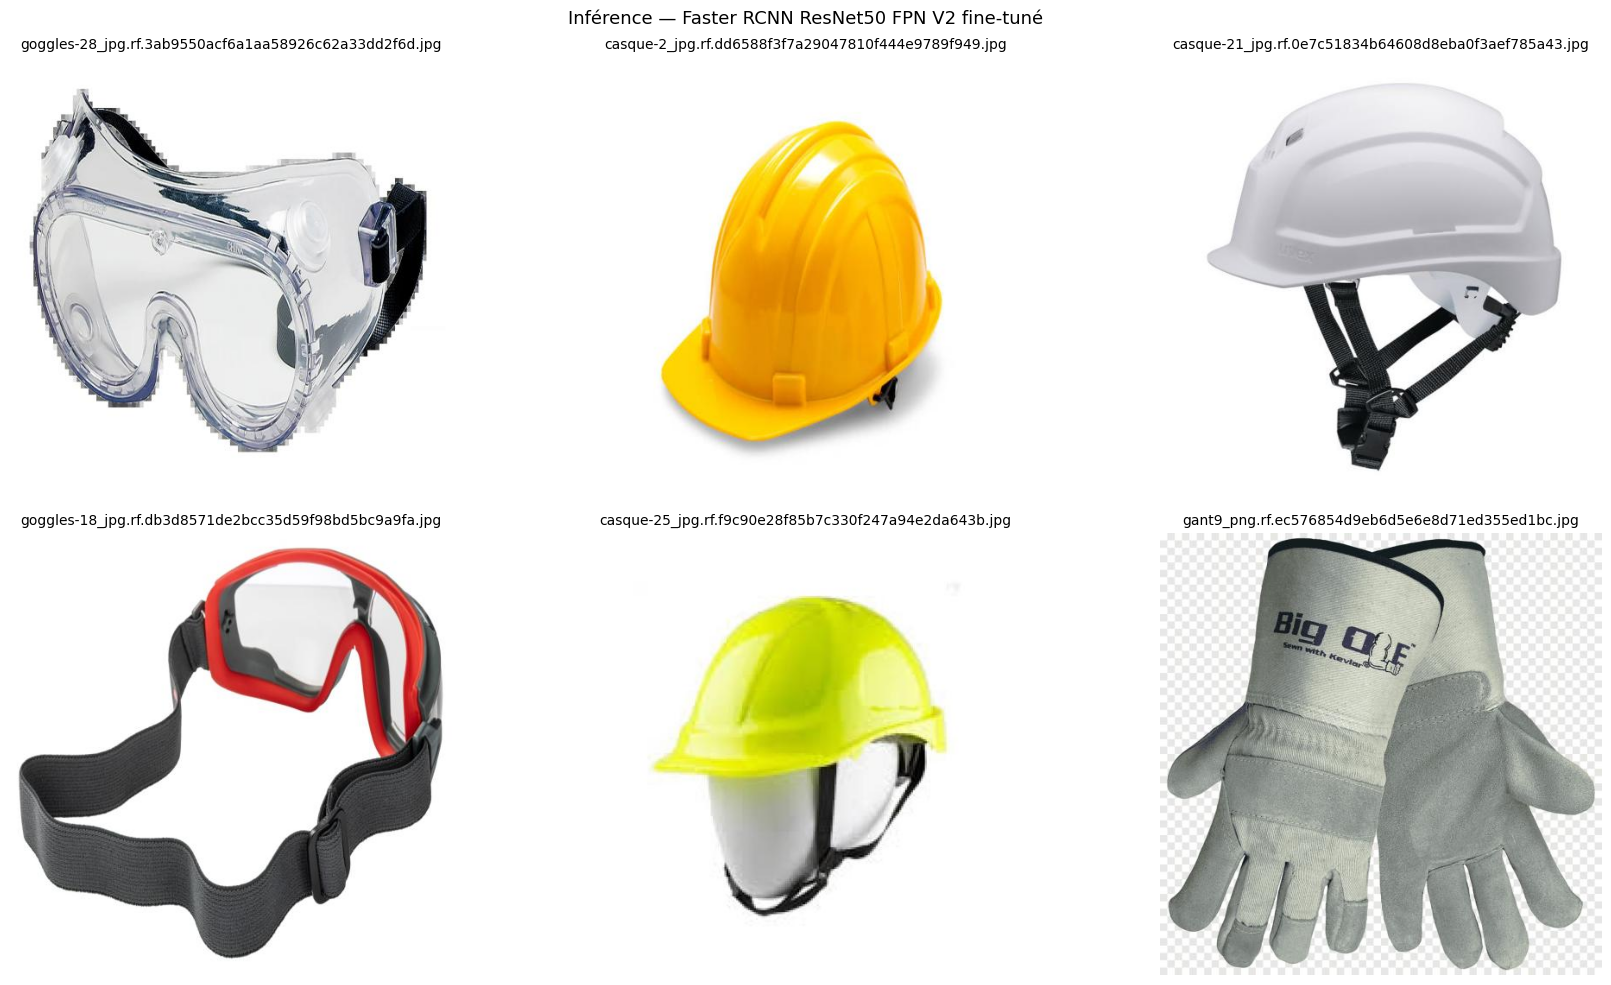

In [7]:
# Lister toutes les images du dossier test
test_images = [
    os.path.join(TEST_DIR, f)
    for f in os.listdir(TEST_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print(f"Images test disponibles : {len(test_images)}")

# Afficher 6 prédictions aléatoires
sample = random.sample(test_images, min(6, len(test_images)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample):
    img_np, boxes, labels, scores = predict(model, img_path, device)
    draw_predictions(
        img_np, boxes, labels, scores,
        title=os.path.basename(img_path),
        ax=ax
    )

plt.suptitle("Inférence — Faster RCNN ResNet50 FPN V2 fine-tuné", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "inference_results.png"), dpi=150)
plt.show()